In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from transformers import RobertaModel, RobertaTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import pandas as pd
from tqdm import tqdm
import pickle


In [2]:
data = pd.read_csv("reviews_22052025_2400.csv")

In [3]:
data.rename(columns={'classification': 'Cluster'}, inplace=True)

In [4]:
df = data[['text','review_count_user', 'average_stars_user', 'yelping_days',
    'useful', 'funny', 'cool', 'fans', 'Cluster']]

In [6]:


# --- CONFIG ---
class Config:
    def __init__(self):
        self.bert_model_name = 'roberta-base'
        self.max_length = 128
        self.batch_size = 8
        self.learning_rate = 2e-5
        self.weight_decay = 0.01
        self.epochs = 20
        self.num_user_features = 7
        self.hidden_size = 64
        self.num_layers = 1
        self.num_filters = 64
        self.filter_sizes = [2, 3, 4]
        self.dropout_prob = 0.4
        self.max_grad_norm = 1.0
        self.warmup_ratio = 0.1
        self.classes = []

config = Config()

# --- ASUME df CARGADO ---
# df debe contener las columnas: 'text', 'Cluster' y las 7 características de usuario

# Mapear clusters a enteros
unique_clusters = df['Cluster'].unique()
cluster_to_int = {cluster: i for i, cluster in enumerate(unique_clusters)}
int_to_cluster = {i: str(cluster) for i, cluster in enumerate(unique_clusters)}  # Para nombres
df['Cluster'] = df['Cluster'].map(cluster_to_int)
config.classes = [str(c) for c in unique_clusters]  # Convertir a str para classification_report

# Separar train/test con estratificación
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].tolist(), df['Cluster'].tolist(),
    test_size=0.2, stratify=df['Cluster'], random_state=42)

tokenizer = RobertaTokenizer.from_pretrained(config.bert_model_name)

def tokenize(texts):
    return tokenizer(texts, padding=True, truncation=True, return_tensors="pt", max_length=config.max_length)

train_inputs = tokenize(train_texts)
test_inputs = tokenize(test_texts)

user_features = ['review_count_user', 'average_stars_user', 'yelping_days',
                 'useful', 'funny', 'cool', 'fans']

train_indices = df[df['text'].isin(train_texts)].index
test_indices = df[df['text'].isin(test_texts)].index

scaler = StandardScaler()
train_user = scaler.fit_transform(df.loc[train_indices, user_features].values)
test_user = scaler.transform(df.loc[test_indices, user_features].values)

train_features = torch.tensor(train_user).float().unsqueeze(1)
test_features = torch.tensor(test_user).float().unsqueeze(1)
train_labels = torch.tensor(train_labels).long()
test_labels = torch.tensor(test_labels).long()

train_dataset = TensorDataset(train_inputs['input_ids'], train_inputs['attention_mask'], train_features, train_labels)
test_dataset = TensorDataset(test_inputs['input_ids'], test_inputs['attention_mask'], test_features, test_labels)
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size)

# --- MODELO ---
class DualAttentionRoberta_mCNN_sBiGRU(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(config.bert_model_name)
        self.roberta_hidden_size = self.roberta.config.hidden_size

        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=self.roberta_hidden_size,
                      out_channels=config.num_filters,
                      kernel_size=fs)
            for fs in config.filter_sizes
        ])
        self.fc_cnn = nn.Linear(len(config.filter_sizes) * config.num_filters, config.hidden_size * 2)

        self.sBiGRU = nn.GRU(
            input_size=config.num_user_features,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            bidirectional=True,
            batch_first=True
        )

        self.attention_user = nn.Sequential(
            nn.Linear(config.hidden_size * 2, config.hidden_size),
            nn.Tanh(),
            nn.Linear(config.hidden_size, 1, bias=False)
        )

        self.attention_text = nn.Sequential(
            nn.Linear(self.roberta_hidden_size, config.hidden_size),
            nn.Tanh(),
            nn.Linear(config.hidden_size, 1, bias=False)
        )

        self.fc_combined = nn.Linear(config.hidden_size * 4, len(config.classes))
        self.dropout = nn.Dropout(config.dropout_prob)
        self.layer_norm = nn.LayerNorm(config.hidden_size * 4)

    def forward(self, input_ids, attention_mask, user_features):
        roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_states = roberta_output.last_hidden_state  # (batch, seq_len, hidden_size)

        text_att_weights = torch.softmax(self.attention_text(last_hidden_states), dim=1)  # (batch, seq_len, 1)
        text_out = torch.sum(text_att_weights * last_hidden_states, dim=1)  # (batch, hidden_size)

        x_conv = last_hidden_states.permute(0, 2, 1)  # (batch, hidden_size, seq_len)
        conv_outputs = [torch.relu(conv(x_conv)).max(dim=2).values for conv in self.convs]
        cnn_output = torch.cat(conv_outputs, dim=1)  # (batch, num_filters * len(filter_sizes))
        cnn_output = torch.relu(self.fc_cnn(cnn_output))  # (batch, hidden_size*2)

        gru_output, _ = self.sBiGRU(user_features)  # (batch, seq_len_user=1, hidden_size*2)
        user_att_weights = torch.softmax(self.attention_user(gru_output), dim=1)
        user_out = torch.sum(user_att_weights * gru_output, dim=1)  # (batch, hidden_size*2)

        combined = torch.cat((cnn_output, user_out), dim=1)  # (batch, hidden_size*4)
        combined = self.layer_norm(combined)
        combined = self.dropout(combined)

        logits = self.fc_combined(combined)
        return logits

# --- FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        else:
            loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

# --- PREDICCIÓN CON UMBRAL AJUSTADO ---
def predict_with_threshold(logits, threshold=0.55):
    probs = torch.softmax(logits, dim=1)[:, 1]
    preds = (probs >= threshold).long()
    return preds

# --- EVALUACIÓN ---
def evaluate_model(model, data_loader):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for input_ids, att_mask, user_feat, labels in data_loader:
            input_ids, att_mask = input_ids.to(device), att_mask.to(device)
            user_feat, labels = user_feat.to(device), labels.to(device)
            outputs = model(input_ids, att_mask, user_feat)
            preds = predict_with_threshold(outputs, threshold=0.55)
            preds_all.append(preds.cpu())
            labels_all.append(labels.cpu())

    preds_all = torch.cat(preds_all).numpy()
    labels_all = torch.cat(labels_all).numpy()

    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average='macro')
    print(classification_report(labels_all, preds_all, target_names=config.classes))

    cm = confusion_matrix(labels_all, preds_all)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=config.classes, yticklabels=config.classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return acc, f1

# --- ENTRENAMIENTO ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DualAttentionRoberta_mCNN_sBiGRU(config).to(device)

classes_np = np.unique(train_labels.numpy())
class_weights_np = compute_class_weight(class_weight='balanced', classes=classes_np, y=train_labels.numpy())
class_weights_np[0] *= 1.5  # reforzar clase 0 manualmente
alpha = torch.tensor(class_weights_np, dtype=torch.float, device=device)
print(f"Alpha para Focal Loss: {dict(zip(classes_np, class_weights_np))}")

criterion = FocalLoss(alpha=alpha, gamma=2.0)
optimizer = AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
total_steps = len(train_loader) * config.epochs
scheduler = get_linear_schedule_with_warmup(optimizer, int(config.warmup_ratio * total_steps), total_steps)

def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs, patience=2):
    best_model = None
    best_f1 = 0
    no_improve = 0

    best_metrics = {}  # Para guardar métricas del mejor modelo

    for epoch in range(epochs):
        # Congelar RoBERTa 2 épocas
        if epoch < 2:
            for param in model.roberta.parameters():
                param.requires_grad = False
        else:
            for param in model.roberta.parameters():
                param.requires_grad = True

        model.train()
        total_loss, correct, total = 0, 0, 0

        for input_ids, att_mask, user_feat, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            input_ids, att_mask = input_ids.to(device), att_mask.to(device)
            user_feat, labels = user_feat.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, att_mask, user_feat)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item() * input_ids.size(0)
            preds = predict_with_threshold(outputs, threshold=0.55)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_loss = total_loss / total

        # Evalúa y captura métricas sin imprimir
        model.eval()
        preds_all, labels_all = [], []
        with torch.no_grad():
            for input_ids, att_mask, user_feat, labels in test_loader:
                input_ids, att_mask = input_ids.to(device), att_mask.to(device)
                user_feat, labels = user_feat.to(device), labels.to(device)
                outputs = model(input_ids, att_mask, user_feat)
                preds = predict_with_threshold(outputs, threshold=0.55)
                preds_all.append(preds.cpu())
                labels_all.append(labels.cpu())

        preds_all = torch.cat(preds_all).numpy()
        labels_all = torch.cat(labels_all).numpy()

        val_acc = accuracy_score(labels_all, preds_all)
        val_f1 = f1_score(labels_all, preds_all, average='macro')
        val_report = classification_report(labels_all, preds_all, target_names=config.classes, output_dict=True)
        val_cm = confusion_matrix(labels_all, preds_all)

        print(f"Epoch {epoch+1} - Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} | Val acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model = copy.deepcopy(model.state_dict())
            no_improve = 0

            # Guarda métricas del mejor modelo
            best_metrics = {
                "val_acc": val_acc,
                "val_f1": val_f1,
                "val_report": val_report,
                "val_cm": val_cm.tolist()  # Convertir a lista para guardar en JSON
            }
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    model.load_state_dict(best_model)
    return model, best_metrics

# --- ENTRENAR ---
model, best_metrics = train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, config.epochs, patience=3)

# Guardar modelo
torch.save(model.state_dict(), "best_model.pth")

# Guardar métricas en JSON para fácil lectura posterior
import json
with open("best_metrics.json", "w") as f:
    json.dump(best_metrics, f, indent=4)




C:\Users\omen\AppData\Local\Temp\ipykernel_6712\3499890637.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = df['Cluster'].map(cluster_to_int)
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Alpha para Focal Loss: {np.int64(0): np.float64(1.5902578796561606), np.int64(1): np.float64(0.9462915601023018)}


Epoch 1: 100%|██████████| 185/185 [00:06<00:00, 27.83it/s]


Epoch 1 - Train loss: 0.3425, Train acc: 0.5014 | Val acc: 0.4811, Val F1: 0.4556


Epoch 2: 100%|██████████| 185/185 [00:05<00:00, 31.49it/s]


...

Epoch 9 - Train loss: 0.0478, Train acc: 0.9736 | Val acc: 0.6946, Val F1: 0.6918


Epoch 10: 100%|██████████| 185/185 [00:24<00:00,  7.59it/s]


Epoch 10 - Train loss: 0.0197, Train acc: 0.9892 | Val acc: 0.6919, Val F1: 0.6917


Epoch 11: 100%|██████████| 185/185 [00:24<00:00,  7.59it/s]


Epoch 11 - Train loss: 0.0216, Train acc: 0.9865 | Val acc: 0.6946, Val F1: 0.6946
Early stopping triggered at epoch 11


Best Validation Accuracy: 0.7054
Best Validation Macro F1: 0.7021

Classification Report:
Class 1: precision=0.71, recall=0.64, f1-score=0.67
Class 0: precision=0.70, recall=0.77, f1-score=0.73


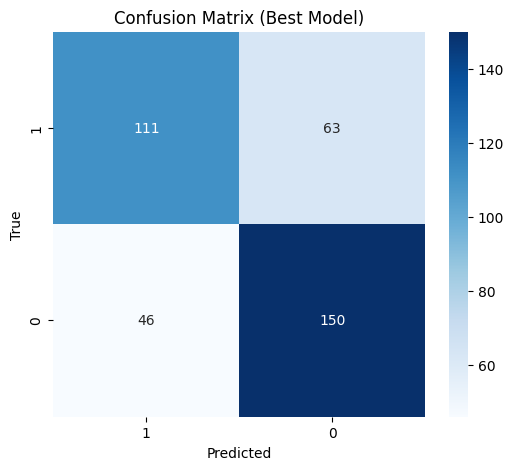

In [7]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar métricas guardadas
with open("best_metrics.json", "r") as f:
    best_metrics = json.load(f)

# Mostrar accuracy y F1
print(f"Best Validation Accuracy: {best_metrics['val_acc']:.4f}")
print(f"Best Validation Macro F1: {best_metrics['val_f1']:.4f}")

# Mostrar classification_report por clase
print("\nClassification Report:")
for cls, metrics in best_metrics['val_report'].items():
    if cls in ['accuracy', 'macro avg', 'weighted avg']:
        continue  # ya mostramos accuracy y macro F1
    print(f"Class {cls}: precision={metrics['precision']:.2f}, recall={metrics['recall']:.2f}, f1-score={metrics['f1-score']:.2f}")

# Mostrar matriz de confusión
cm = best_metrics["val_cm"]
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=config.classes, yticklabels=config.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Best Model)')
plt.show()


In [8]:
import pandas as pd
import torch

# --- Cargar datos ---
df = pd.read_csv("reviews_22052025_100.csv")

# --- Definir columnas ---
user_features = ['review_count_user', 'average_stars_user', 'yelping_days',
                 'useful', 'funny', 'cool', 'fans']

texts = df['text'].tolist()

# --- Cargar modelo, scaler y tokenizer ---
from transformers import RobertaTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_all(model_class, config, path_prefix="best_model", device=device):
    import joblib
    model = model_class(config)
    model.load_state_dict(torch.load(f"{path_prefix}_model.pt", map_location=device))
    model.to(device)
    model.eval()
    scaler = joblib.load(f"{path_prefix}_scaler.pkl")
    tokenizer = RobertaTokenizer.from_pretrained(f"{path_prefix}_tokenizer")
    return model, scaler, tokenizer

# Carga modelo y utilidades
model, scaler, tokenizer = load_all(DualAttentionRoberta_mCNN_sBiGRU, config, "best_model", device)

# --- Preparar datos para evaluación ---
def prepare_data_for_eval(texts, user_df, scaler, tokenizer, config, device):
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=config.max_length, return_tensors='pt')
    user_features_scaled = scaler.transform(user_df[user_features].values)
    user_tensor = torch.tensor(user_features_scaled).float().unsqueeze(1).to(device)
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    return input_ids, attention_mask, user_tensor

input_ids, attention_mask, user_tensor = prepare_data_for_eval(texts, df, scaler, tokenizer, config, device)

# --- Predecir con umbral ajustado ---
def predict_with_threshold(logits, threshold=0.55):
    probs = torch.softmax(logits, dim=1)[:, 1]
    preds = (probs >= threshold).long()
    return preds

with torch.no_grad():
    outputs = model(input_ids, attention_mask, user_tensor)
    preds = predict_with_threshold(outputs, threshold=0.55)

# --- Mostrar resultados ---
print("Predicciones de clusters:")
print(preds.cpu().numpy())


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Predicciones de clusters:
[1 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 0 1 0 0
 1 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 0 0 0 0 1 1 0 1 0 1 1 0 1 1 0 1 1 0
 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 0 1 1]


In [9]:
from sklearn.metrics import classification_report, accuracy_score

true_labels = df['Cluster'].values
pred_labels = preds.cpu().numpy()

# Mostrar accuracy y reporte completo
print("Accuracy:", accuracy_score(true_labels, pred_labels))
print(classification_report(true_labels, pred_labels, digits=2))

Accuracy: 0.28
              precision    recall  f1-score   support

           0       0.26      0.21      0.23        52
           1       0.29      0.35      0.32        48

    accuracy                           0.28       100
   macro avg       0.28      0.28      0.28       100
weighted avg       0.28      0.28      0.28       100



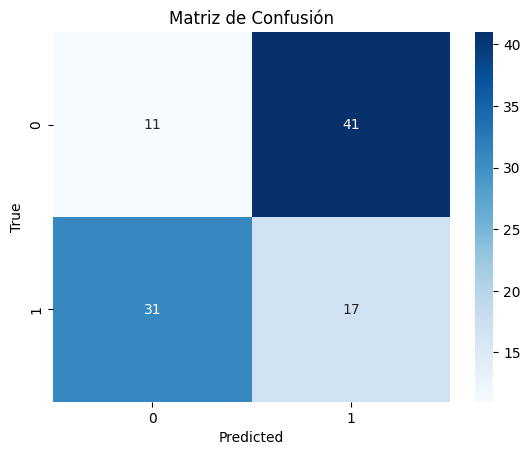

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Matriz de Confusión")
plt.show()